# Exercise 5: Variational Auto Encoder
## Submission date: 08\06\2026, 23:59.

Submitted by:

 **Student 1 : Baruh Riss 318739174

 **Student 2 : Amir Ammar 205744873
 
<font color='red'>Before submission, please make sure that all the plots and results are present as a colab notebook file</font>


## Configurations and initializations

This section loads libraries and configurations for various tasks for this course

In [2]:
## Standard libraries
import os
import math
import numpy as np
import pandas as pd
from collections import defaultdict

## Imports for plotting
import matplotlib.pyplot as plt
plt.set_cmap('cividis')
%matplotlib inline
from IPython.display import set_matplotlib_formats
%config InlineBackend.figure_formats = ['svg', 'pdf']
from matplotlib.colors import to_rgb
import seaborn as sns

## Progress bar
from tqdm.notebook import tqdm

## PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.utils.data as data
import torch.optim as optim
import torch.distributions as dist

# Torchvision
import torchvision
from torchvision.datasets import MNIST
from torchvision import transforms

# Path to the folder where the datasets are/should be downloaded (e.g. MNIST)
DATASET_PATH = "../data"

# Path to the folder where the models are saved
CHECKPOINT_PATH = "./"

# Ensure reproducibility as much as possible
np.random.seed(42)
torch.manual_seed(42)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Fetching the device that will be used throughout this notebook
device = torch.device("cpu") if not torch.cuda.is_available() else torch.device("cuda:0")
print("Using device", device)


Using device cuda:0


<Figure size 640x480 with 0 Axes>

In [3]:
def dequantize_mnist(img):
    x = torch.from_numpy(np.array(img, dtype=np.float32)).unsqueeze(0)
    return (x + torch.rand_like(x)) / 256.0

# Continuous representation: add U[0,1] noise to integer pixels, then scale by 256.
transform = transforms.Compose([
    transforms.Lambda(dequantize_mnist),
])

# Loading the training dataset. We need to split it into a training and validation part
train_dataset = MNIST(root=DATASET_PATH, train=True, transform=transform, download=True)

split_generator = torch.Generator().manual_seed(42)
train_set, val_set = torch.utils.data.random_split(train_dataset, [50000, 10000], generator=split_generator)

# Loading the test set
test_set = MNIST(root=DATASET_PATH, train=False, transform=transform, download=True)

# We define a set of data loaders that we can use for various purposes later.
train_loader = data.DataLoader(train_set, batch_size=128, shuffle=True, drop_last=True, pin_memory=True, num_workers=0)
val_loader = data.DataLoader(val_set, batch_size=128, shuffle=False, drop_last=False, num_workers=0)
test_loader = data.DataLoader(test_set, batch_size=128, shuffle=False, drop_last=False, num_workers=0)

print('Train size:', len(train_loader.dataset))
print('Validation size:', len(val_loader.dataset))
print('Test size:', len(test_loader.dataset))


Train size: 50000
Validation size: 10000
Test size: 10000


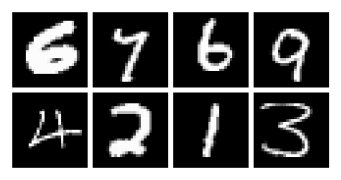

In [4]:
def show_imgs(imgs):
    num_imgs = imgs.shape[0] if isinstance(imgs, torch.Tensor) else len(imgs)
    nrow = min(num_imgs, 4)
    ncol = int(math.ceil(num_imgs/nrow))
    imgs = torchvision.utils.make_grid(imgs, nrow=nrow, pad_value=128)
    imgs = imgs.clamp(min=0, max=1)
    np_imgs = imgs.cpu().numpy()
    plt.figure(figsize=(1.5*nrow, 1.5*ncol))
    plt.imshow(np.transpose(np_imgs, (1,2,0)), interpolation='nearest')
    plt.axis('off')
    plt.show()

show_imgs([train_set[i][0] for i in range(8)])

# A Theoretical and Practical Analysis of the Variational Autoencoder (VAE)

The provided PyTorch implementation elegantly bridges the continuous, integral-heavy mathematics of Variational Inference with discrete, tensor-based deep learning operations.

Here is a deep dive into how each component of this code translates the mathematical theory of VAEs into a computable, differentiable architecture.

---

## 1. The Statistical Proxies: `__init__`

In traditional statistics, inference involves solving intractable integrals to find the true posterior $p(z|x)$. In the VAE framework, we bypass this by using highly non-linear function approximators (neural networks) to parameterize these distributions.

* **`self.encoder` & `self.encoder_fc**`: These layers collectively represent the parameters $\phi$ of our approximate posterior $q_\phi(z|x)$. Instead of calculating the exact distribution, the network learns to map an input image to the *parameters* of a Gaussian distribution.
* **`self.decoder_fc` & `self.decoder_conv**`: These layers represent the parameters $\theta$ of the generative likelihood $p_\theta(x|z)$. They map a latent vector back to the spatial dimensions of the original image.
* **`self.decoder_sigma`**: This constant ($0.1$) is a crucial theoretical anchor. By fixing the variance of the decoder's output distribution, we mathematically reduce the negative log-likelihood to a scaled Mean Squared Error (MSE), simplifying optimization while maintaining probabilistic rigor.

---

## 2. Parameterizing the Approximate Posterior: `encode(self, x)`

```python
mu = self.fc_mu(h)
log_std = self.fc_log_std(h).clamp(min=-6.0, max=2.0)
std = torch.exp(log_std)
q_z_given_x = dist.Independent(dist.Normal(mu, std), 1)

```

**Theoretical Connection:** This function defines $q_\phi(z|x) \sim \mathcal{N}(\mu, \sigma^2 I)$.
Notice that the network outputs `log_std` rather than standard deviation directly. This is a vital engineering practice in deep generative models. Standard deviations must strictly be positive. If we output $\sigma$ directly, the network might predict a negative value, breaking the math. By outputting $\log \sigma$ (which can span $[-\infty, \infty]$) and then exponentiating it, we guarantee a positive $\sigma$. The `clamp` operation prevents numerical overflow/underflow (exploding or vanishing variances) during early training epochs.

The use of `dist.Independent(..., 1)` tells PyTorch to treat the final dimension as independent, multivariate Gaussian distributions with a diagonal covariance matrix, matching the theoretical assumption that our latent dimensions do not directly interact.

---

## 3. The Reparameterization Trick: `forward(self, x)`

```python
q_z_given_x, _, _ = self.encode(x)
z = q_z_given_x.rsample()

```

**Theoretical Connection:**
This is the heart of the VAE. To train the network, we must optimize the expectation over $q(z|x)$, which requires sampling $z \sim q_\phi(z|x)$. However, sampling is a stochastic, non-differentiable operation; you cannot pass gradients backward through a random node.

The `rsample()` method implements the **Reparameterization Trick**: $z = \mu + \sigma \odot \epsilon$, where $\epsilon \sim \mathcal{N}(0, I)$.
By moving the randomness into an auxiliary variable $\epsilon$, the nodes $\mu$ and $\sigma$ remain deterministic relative to the input $x$. This allows the gradients to flow freely backward from the loss function, through $z$, and into the encoder's parameters $\phi$.

---

## 4. The Generative Model: `decode` & `prior`

```python
def prior(self, batch_size):
    z_loc = torch.zeros(...)
    z_scale = torch.ones_like(...)
    return dist.Independent(dist.Normal(z_loc, z_scale), 1)

```

**Theoretical Connection:**
The `prior` function defines $p(z) \sim \mathcal{N}(0, I)$, the standard isotropic Gaussian. This acts as the structural foundation of the latent space. We assume that the latent semantic features of the data are normally distributed around the origin.

The `decode(self, z)` function computes the mean of the likelihood distribution $p_\theta(x|z)$. The final `nn.Sigmoid()` in the decoder architecture ensures the output pixels are bounded between $[0, 1]$, treating the reconstruction as the mean of a continuous distribution.

---

## 5. The Objective: `calc_elbo(self, batch)`

```python
recon_nll = -p_x_given_z.log_prob(batch).mean()
kld = dist.kl_divergence(q_z_given_x, p_z).mean()
negative_elbo = recon_nll + kld

```

**Theoretical Connection:**
Because the true log-evidence $\log p(x)$ is intractable, we optimize its lower bound, the ELBO (Evidence Lower Bound):


$$\mathcal{L}(\theta, \phi; x) = \mathbb{E}_{q_\phi(z|x)}[\log p_\theta(x|z)] - D_{KL}(q_\phi(z|x) || p(z))$$

Since PyTorch optimizers *minimize* loss, we minimize the **negative ELBO**:

1. **`recon_nll` (Reconstruction Loss):** This represents $-\mathbb{E}_{q}[\log p_\theta(x|z)]$. By evaluating the negative log-probability (`log_prob`) of the actual batch under the decoder's predicted distribution, we penalize the model when it fails to reconstruct the input.
2. **`kld` (KL Divergence):** This is the regularizer $D_{KL}(q_\phi(z|x) || p(z))$. It measures the informational "distance" between the encoder's predicted posterior and the standard normal prior.

**The Tug-of-War:** `recon_nll` wants the variance ($\sigma$) to be zero and the means ($\mu$) to be spread far apart to memorize the dataset perfectly.
`kld` wants the variance to be $1$ and the means to be $0$ to perfectly match the prior.
The optimal point—the maximum ELBO—forces the network to learn a smooth, continuous latent representation that is dense around the origin, enabling the generation of novel, coherent data via the `sample()` function.



### Part A: The Reconstruction Loss (`recon_nll`)

This term represents $-\mathbb{E}_{q}[\log p_\theta(x|z)]$ and measures how well the network reconstructs the original image. By evaluating the negative log-probability (`log_prob`) of the actual batch under the decoder's predicted distribution, we penalize the model for pixel-level errors.

**How it is calculated:**
We define the decoder's output as the mean of a Gaussian distribution with a fixed, constant variance ($\sigma = 0.1$). Mathematically, the negative log-likelihood of a Gaussian expands to:

$$-\log p(x|z) = \frac{1}{2\sigma^2} ||x - \hat{x}||^2 + C$$

Where:

* $x$ is the true input image.
* $\hat{x}$ is the image predicted by the decoder.
* $||x - \hat{x}||^2$ is the Mean Squared Error (MSE).

By fixing `decoder_sigma = 0.1`, the scaling coefficient becomes $\frac{1}{2(0.1^2)} = \frac{1}{0.02} = \mathbf{50}$. Therefore, the `recon_nll` in practice calculates a scaled Mean Squared Error (MSE multiplied by 50) plus a constant. This heavy scaling forcefully drives the model to produce sharp, accurate image reconstructions.

### Part B: The KL Divergence (`kld`)

This is the regularizer $D_{KL}(q_\phi(z|x) || p(z))$. It measures the informational "distance" between the encoder's predicted posterior and the standard normal prior $\mathcal{N}(0, I)$.

**How it is calculated:**
Because both our approximate posterior $q(z|x)$ and our prior $p(z)$ are chosen to be Gaussian distributions, PyTorch's `dist.kl_divergence` does not need to estimate this via sampling; it calculates it using a closed-form analytical solution. For a latent space of $J$ dimensions, the formula is:

$$D_{KL}(q_\phi(z|x) || p(z)) = -\frac{1}{2} \sum_{j=1}^J \left( 1 + \log(\sigma_j^2) - \mu_j^2 - \sigma_j^2 \right)$$

This elegant formula acts as a strict penalty system:

* If $\mu_j$ moves away from $0$, the loss increases.
* If $\sigma_j^2$ deviates from $1$, the loss increases.

### The Tug-of-War

The final `negative_elbo` simply sums these two calculated components.

* `recon_nll` wants the variance to shrink to zero and the means to be spaced infinitely far apart so it can memorize the training set perfectly without noise.
* `kld` fights back, punishing the network heavily if the variance drops below 1 or if the means drift away from the origin.

The optimal point—the maximum ELBO—forces the network to find a mathematical compromise. It learns a smooth, continuous latent representation that is densely packed around the origin (satisfying the KL term) while still preserving enough distinct features to accurately rebuild the digits (satisfying the Reconstruction term). This balance is what fundamentally enables the VAE to generate novel, coherent data.

___
## Task 1
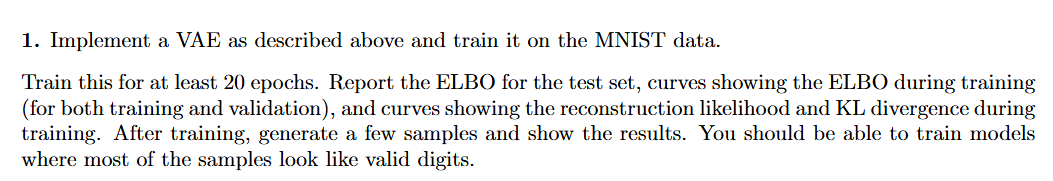
___

In [ ]:

class VAE(nn.Module):
    """
    Variational Autoencoder (VAE) architecture for continuous data.
    
    This class implements a Convolutional VAE that learns a smooth latent 
    representation of image data. It optimizes the Evidence Lower Bound (ELBO) 
    using the reparameterization trick, balancing a reconstruction objective 
    (negative log-likelihood) with a regularization objective (KL divergence 
    against an isotropic Gaussian prior).
    """

    def __init__(self, latent_dim, decoder_sigma=0.1):
        """
        Initializes the VAE components including the encoder, latent projections, and decoder.
        
        Args:
            latent_dim (int): The dimensionality of the bottleneck latent space (z).
            decoder_sigma (float): The fixed standard deviation for the decoder's output 
                                   distribution, used to scale the reconstruction loss.
        """
        # Call the parent nn.Module initialization to register parameters
        super().__init__()

        # Store the target dimensionality of the latent space (z)
        self.latent_dim = latent_dim
        
        # Store the fixed standard deviation for the generative likelihood p(x|z). 
        # A value of 0.1 means we mathematically treat the reconstruction loss as 
        # a scaled Mean Squared Error.
        self.decoder_sigma = decoder_sigma

        # ==========================================
        # ENCODER (Approximate Posterior: q(z|x))
        # ==========================================
        
        # The convolutional frontend of the encoder. Extracts spatial features and downsamples.
        self.encoder = nn.Sequential(
            # Input: 1 channel (grayscale), Output: 32 channels. Stride 2 halves the spatial dimensions (28x28 -> 14x14).
            nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1),
            # Non-linear activation function to learn complex mappings.
            nn.ReLU(),
            # Output: 64 channels. Stride 2 halves dimensions again (14x14 -> 7x7).
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            # Output: 128 channels. Stride 1 maintains spatial dimensions (7x7 -> 7x7).
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            # Flattens the 3D tensor (Channels x Height x Width) into a 1D vector per batch item 
            # so it can be passed into linear layers.
            nn.Flatten(),
        )
        
        # The fully connected backend of the encoder. Processes the flattened spatial features.
        self.encoder_fc = nn.Sequential(
            # Maps the flattened tensor (128 channels * 7 height * 7 width) to a 256-dim hidden state.
            nn.Linear(128 * 7 * 7, 256),
            nn.ReLU(),
            # Maps the 256-dim hidden state to a 128-dim feature vector.
            nn.Linear(256, 128),
            nn.ReLU(),
        )
        
        # Linear layer projecting the 128-dim features to the Mean (mu) of the latent distribution.
        self.fc_mu = nn.Linear(128, latent_dim)
        
        # Linear layer projecting the 128-dim features to the Log-Standard Deviation of the latent distribution.
        # We output log(std) instead of std directly because neural networks can output negative numbers, 
        # but standard deviation must be strictly positive.
        self.fc_log_std = nn.Linear(128, latent_dim)

        # ==========================================
        # DECODER (Generative Likelihood: p(x|z))
        # ==========================================
        
        # The fully connected frontend of the decoder. Expands the low-dimensional latent vector z.
        self.decoder_fc = nn.Sequential(
            # Maps the latent vector z back to a 128-dim hidden state.
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            # Expands the 128-dim state to a 256-dim state.
            nn.Linear(128, 256),
            nn.ReLU(),
            # Expands the 256-dim state to match the exact size needed for the convolutional feature maps (128 * 7 * 7).
            nn.Linear(256, 128 * 7 * 7),
            nn.ReLU(),
        )
        
        # The convolutional backend of the decoder. Upsamples features back into an image.
        self.decoder_conv = nn.Sequential(
            # Reshapes the flat vector back into a 3D tensor (128 channels, 7 height, 7 width).
            nn.Unflatten(1, (128, 7, 7)),
            # Transposed convolution (Deconvolution) with stride 2 doubles the spatial dimensions (7x7 -> 14x14).
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            # Transposed convolution with stride 2 doubles dimensions again (14x14 -> 28x28).
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            # Standard convolution with stride 1 to map the 32 channels down to 1 single image channel (grayscale).
            nn.Conv2d(32, 1, kernel_size=3, stride=1, padding=1),
            # Sigmoid activation bounds the output pixel values strictly between [0.0, 1.0], treating them as probabilities/intensities.
            nn.Sigmoid(),
        )

        # Dictionary to store loss metrics over time for tracking and plotting.
        self.logs = defaultdict(list)

    def log(self, key, value):
        """
        Helper method to append a scalar value to the internal logging dictionary.
        """
        # Appends the value to the list corresponding to the specified key.
        self.logs[key].append(value)

    def encode(self, x):
        """
        Passes the input through the encoder network to yield the approximate posterior distribution q(z|x).
        q(z|x) ~ Normal(mu, sigma^2 * I)
        
        Args:
            x (Tensor): The input image batch.
            
        Returns:
            q_z_given_x (torch.distributions.Distribution): The parameterized Gaussian distribution.
            mu (Tensor): The mean of the distribution.
            log_std (Tensor): The log standard deviation of the distribution.
        """
        # Pass the input batch through the convolutional layers.
        h = self.encoder(x)
        # Pass the flattened spatial features through the fully connected layers.
        h = self.encoder_fc(h)
        
        # Calculate the mean (mu) vector for the Gaussian distribution.
        mu = self.fc_mu(h)
        
        # Calculate the log standard deviation. The clamp() operation is a crucial stability trick:
        # it prevents the variance from exploding (max=2.0) or vanishing to exactly zero (min=-6.0), 
        # which would cause NaNs during optimization.
        log_std = self.fc_log_std(h).clamp(min=-6.0, max=2.0)
        
        # Exponentiate the log_std to get the actual standard deviation (which is now guaranteed to be positive).
        std = torch.exp(log_std)
        
        # Construct the Gaussian distribution object. 
        # dist.Independent(..., 1) is used to tell PyTorch that the last dimension (the latent dimension) 
        # represents independent variables, creating a multivariate normal with a diagonal covariance matrix.
        q_z_given_x = dist.Independent(dist.Normal(mu, std), 1)
        
        # Return the distribution object along with its raw parameters for potential later use.
        return q_z_given_x, mu, log_std

    def decode(self, z):
        """
        Passes the latent vector z through the decoder network to reconstruct the image.
        Computes the mean (x_hat) of the likelihood distribution:
        p(x|z) ~ Normal(x_hat, decoder_sigma^2 * I)
        Args:
            z (Tensor): The sampled latent vector.
            
        Returns:
            Tensor: The reconstructed image (the mean of the likelihood distribution p(x|z)).
        """
        # Pass the latent vector through the fully connected expansion layers.
        h = self.decoder_fc(z)
        # Reshape and pass through transposed convolutions to generate the final image tensor.
        return self.decoder_conv(h)

    def prior(self, batch_size):
        """
        Constructs the prior distribution p(z), which is a standard isotropic Gaussian N(0, I).
        
        Args:
            batch_size (int): The number of prior distributions to create (to match the batch).
            
        Returns:
            p_z (torch.distributions.Distribution): The standard normal prior distribution.
        """
        # Create a tensor of zeros for the mean, ensuring it resides on the same device (CPU/GPU) as the model.
        z_loc = torch.zeros(batch_size, self.latent_dim, device=next(self.parameters()).device)
        # Create a tensor of ones for the standard deviation (variance = 1).
        z_scale = torch.ones_like(z_loc)
        
        # Return the distribution as an independent multivariate Gaussian.
        return dist.Independent(dist.Normal(z_loc, z_scale), 1)

    def forward(self, x):
        """
        Forward pass implementing the Reparameterization Trick.
        To sample from q(z|x) differentiably, we compute:
        
        z = mu + (sigma * epsilon)
        where epsilon ~ Normal(0, 1)
        
        Args:
            x (Tensor): The input image batch.
            
        Returns:
            x_mean (Tensor): The reconstructed images.
            q_z_given_x (Distribution): The encoder's posterior distribution.
            z (Tensor): The actual latent vector sampled from the distribution.
        """
        # 1. Encode: Get the posterior distribution q(z|x) from the input image.
        q_z_given_x, _, _ = self.encode(x)
        
        # 2. Sample (Reparameterization Trick): rsample() computes z = mu + std * epsilon, where epsilon ~ N(0,1).
        # This allows gradients to backpropagate through the stochastic sampling process.
        z = q_z_given_x.rsample()
        
        # 3. Decode: Generate the reconstructed image from the sampled latent vector.
        x_mean = self.decode(z)
        
        # Return the reconstruction, the distribution (needed for KL divergence), and the sample.
        return x_mean, q_z_given_x, z

    def calc_elbo(self, batch):
        """
        Calculates the Evidence Lower Bound (ELBO), which serves as the loss function.
        
        Args:
            batch (Tensor): The true input image batch.
            
        Returns:
            negative_elbo (Tensor): The scalar loss to be minimized.
            recon_nll (Tensor): The reconstruction loss component.
            kld (Tensor): The KL divergence component.
        """
        # Run the full forward pass to get reconstructions and the approximate posterior distribution.
        # Math: x_hat = decoder(z), where z ~ q(z|x)
        x_mean, q_z_given_x, _ = self.forward(batch)
        
        # Define the likelihood distribution p(x|z) as a Gaussian centered at the decoder's output (x_mean),
        # with the constant, pre-defined standard deviation (self.decoder_sigma).
        # Math: p(x|z) ~ Normal(x_hat, decoder_sigma^2)
        # dist.Independent(..., 3) treats the 3 image dimensions (C, H, W) as independent.
        p_x_given_z = dist.Independent(
            dist.Normal(x_mean, torch.full_like(x_mean, self.decoder_sigma)),
            3,
        )
        
        # Get the prior distribution p(z) to compare against our posterior.
        # Math: p(z) ~ Normal(0, I)
        p_z = self.prior(batch.size(0))

        # RECONSTRUCTION TERM: Calculate the negative log-likelihood of the true batch under the decoder's distribution.
        # Because we fixed the variance, mathematically this is equivalent to a scaled Mean Squared Error.
        # Math: -Expectation [ log(p(x|z)) ] ~= (1 / (2 * sigma^2)) * ||x - x_hat||^2 + constant
        recon_nll = -p_x_given_z.log_prob(batch).mean()
        
        # REGULARIZATION TERM: Calculate the Kullback-Leibler (KL) Divergence between the predicted posterior q(z|x) and the prior p(z).
        # This penalizes the model if the latent space strays too far from a standard normal distribution.
        # Math: KL( q(z|x) || p(z) )
        # Because both are Gaussian, this expands analytically to:
        # = -0.5 * sum( 1 + log(sigma^2) - mu^2 - sigma^2 )
        kld = dist.kl_divergence(q_z_given_x, p_z).mean()
        
        # TOTAL LOSS: We minimize the negative ELBO, which is the sum of the reconstruction penalty and the KL penalty.
        negative_elbo = recon_nll + kld
        
        return negative_elbo, recon_nll, kld

    @torch.no_grad()
    def sample(self, num_samples):
        """
        Generates completely new images by sampling directly from the prior latent space.
        Uses @torch.no_grad() because we don't need to track gradients for generation.
        
        Args:
            num_samples (int): The number of images to generate.
            
        Returns:
            Tensor: A batch of generated images.
        """
        # Sample pure random noise (epsilon) from a standard normal distribution N(0,1).
        z = torch.randn(num_samples, self.latent_dim, device=next(self.parameters()).device)
        
        # Pass the random noise through the decoder to hallucinate new images.
        return self.decode(z)

    def training_step(self, batch):
        """
        Executes a single training iteration for a batch of data.
        
        Args:
            batch (Tensor): The training data batch.
            
        Returns:
            Tuple containing total loss, reconstruction loss, and KL divergence.
        """
        # Calculate the objective function (ELBO) and its components.
        loss, rec_loss, KLD = self.calc_elbo(batch)
        
        # Store the current values in the logs dictionary for later analysis/plotting.
        # .item() extracts the float value from the PyTorch scalar tensor to save GPU memory.
        self.log('train_elbo', loss.item())
        self.log('train_recon', rec_loss.item())
        self.log('train_KLD', KLD.item())
        
        # Return the total loss so the external optimizer can call .backward() on it.
        return loss, rec_loss, KLD

    @torch.no_grad()
    def validation_step(self, loader):
        """
        Evaluates the model over an entire validation dataloader without computing gradients.
        
        Args:
            loader (DataLoader): The PyTorch DataLoader containing validation data.
            
        Returns:
            loss (Tensor): The average validation ELBO.
        """
        # Initialize a tensor to accumulate the sum of ELBO, Recon, and KLD.
        metric_sums = torch.zeros(3)
        num_examples = 0
        
        # Iterate over the batches in the dataloader, showing a progress bar via tqdm.
        for imgs, _ in tqdm(loader, leave=False):
            # Move the images to the global computation device (assumes 'device' is defined globally).
            imgs = imgs.to(device)
            
            # Calculate the metrics for this batch. .detach().cpu() removes the computational graph
            # and moves the tensor to CPU memory to prevent RAM leaks during evaluation.
            metrics = torch.stack(self.calc_elbo(imgs)).detach().cpu()
            
            # Multiply by batch size (imgs.size(0)) to get the absolute sum, preventing skew from uneven final batches.
            metric_sums += metrics * imgs.size(0)
            # Track the total number of images processed.
            num_examples += imgs.size(0)

        # Divide the accumulated sums by the total number of images to get true epoch averages.
        loss, rec_loss, KLD = metric_sums / num_examples
        
        # Log the averaged validation metrics.
        self.log('val_elbo', loss.item())
        self.log('val_recon', rec_loss.item())
        self.log('val_KLD', KLD.item())

        return loss

    @torch.no_grad()
    def test_step(self, loader):
        """
        Evaluates the model over an entire test dataloader. Functionally identical to validation_step.
        
        Args:
            loader (DataLoader): The PyTorch DataLoader containing test data.
            
        Returns:
            loss (Tensor): The average test ELBO.
        """
        # Initialize an accumulator for the 3 metrics.
        metric_sums = torch.zeros(3)
        num_examples = 0
        
        # Iterate over the test batches.
        for imgs, _ in tqdm(loader, leave=False):
            # Move images to the correct hardware device.
            imgs = imgs.to(device)
            
            # Calculate ELBO and move results to CPU.
            metrics = torch.stack(self.calc_elbo(imgs)).detach().cpu()
            
            # Accumulate totals weighted by batch size.
            metric_sums += metrics * imgs.size(0)
            num_examples += imgs.size(0)

        # Calculate final averages over the test set.
        loss, rec_loss, KLD = metric_sums / num_examples
        
        # Log the test metrics under 'test_' keys.
        self.log('test_elbo', loss.item())
        self.log('test_recon', rec_loss.item())
        self.log('test_KLD', KLD.item())

        return loss


### Model Training

In [45]:
import torch.optim as optim

# ==========================================
# 1. LATENT DIMENSION (CRITICAL FOR VISUALIZATION)
# ==========================================
# If your assignment asks you to plot a 2D "Latent Manifold" grid (where digits morph 
# across an X and Y axis), you MUST set this to 2. 
# If it only asks for reconstruction and linear interpolation, 32 will yield sharper images.
latent_dim = 64

# Initialize the model and move it to the appropriate device (GPU/CPU)
model = VAE(latent_dim=latent_dim, decoder_sigma=0.1).to(device)
print(f"Num params: {sum(p.numel() for p in model.parameters()):,}")

# ==========================================
# 2. OPTIMIZER & SCHEDULER
# ==========================================
# Adam with a learning rate of 1e-3 is the standard for VAEs. 
# Notice we DO NOT use weight_decay (L2 regularization) because the KL divergence 
# term in the ELBO already acts as our regularizer.
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# --- CHANGED: Smarter Learning Rate Scheduler ---
# ReduceLROnPlateau watches the validation loss. If it doesn't improve for 3 epochs (patience=3),
# it cuts the learning rate in half (factor=0.5) to help fine-tune the weights without bouncing.
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3, verbose=True)

# ==========================================
# 3. EPOCHS & ADVANCED TRAINING SETTINGS
# ==========================================
# 100 epochs is overkill for MNIST and will waste your Colab GPU time. 
# A standard VAE on MNIST usually converges and plateaus around epoch 20-30.
epochs = 30

# --- NEW: Early Stopping & KL Annealing Trackers ---
patience = 5                 # Stop training entirely if validation loss doesn't improve for 5 epochs
epochs_no_improve = 0        # Counter to track early stopping patience
warmup_epochs = 10           # Number of epochs to linearly scale the KL divergence weight (beta) from 0.0 to 1.0
best_val_elbo = float('inf') # Initialize the best validation loss tracker

Num params: 3,565,441


/home/aammar/GM/.venv/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


In [46]:
history = defaultdict(list)
best_val_elbo = float('inf') # Track the best validation loss

# --- NEW: Early Stopping & KL Annealing Trackers ---
patience = 5                 # Stop training entirely if validation loss doesn't improve for 5 epochs
epochs_no_improve = 0        # Counter to track early stopping patience
warmup_epochs = 10           # Epochs to linearly scale the KL divergence weight (beta) from 0.0 to 1.0

# Training loop
for epoch in range(epochs):
    model.train()
    metric_sums = torch.zeros(3)
    num_examples = 0
    
    # --- NEW: KL Annealing Weight (Beta) ---
    # Starts at 0.0, linearly increases to 1.0 by epoch 10
    beta = min(1.0, epoch / warmup_epochs)

    for imgs, _ in tqdm(train_loader, leave=False, desc=f"Epoch {epoch + 1}/{epochs}"):
        imgs = imgs.to(device)
        optimizer.zero_grad()
        
        # We get the raw losses from the model
        loss, rec_loss, KLD = model.training_step(imgs)
        
        # --- NEW: Apply Beta to the Backprop Loss ---
        # We manually recalculate the total loss with the beta weight for backpropagation
        annealed_loss = rec_loss + (beta * KLD)
        
        # Backpropagate using the ANNEALED loss
        annealed_loss.backward()
        
        # Gradient Clipping (Prevents exploding gradients from the exponentiated variance)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()

        # Keep tracking the true (unweighted) metrics for your history logs
        batch_metrics = torch.tensor([loss.item(), rec_loss.item(), KLD.item()])
        metric_sums += batch_metrics * imgs.size(0)
        num_examples += imgs.size(0)

    # Calculate training averages
    train_loss, train_recon, train_KLD = metric_sums / num_examples
    history['train_elbo'].append(train_loss.item())
    history['train_recon'].append(train_recon.item())
    history['train_KLD'].append(train_KLD.item())

    # Validation Phase
    model.eval()
    val_loss = model.validation_step(val_loader)
    
    current_val_elbo = model.logs['val_elbo'][-1]
    history['val_elbo'].append(current_val_elbo)
    history['val_recon'].append(model.logs['val_recon'][-1])
    history['val_KLD'].append(model.logs['val_KLD'][-1])

    # --- CHANGED: Step the Scheduler HERE ---
    # ReduceLROnPlateau must be stepped AFTER validation, passing in the current val loss
    scheduler.step(current_val_elbo)

    # --- NEW: Save Best Model & Early Stopping Logic ---
    save_msg = ""
    if current_val_elbo < best_val_elbo:
        best_val_elbo = current_val_elbo
        epochs_no_improve = 0 # Reset patience counter
        save_msg = "--> Checkpoint Saved!"
        
        # Save the model
        torch.save({
            'model_state_dict': model.state_dict(),
            'latent_dim': latent_dim,
            'decoder_sigma': model.decoder_sigma,
            'history': dict(history),
            'epoch': epoch + 1
        }, os.path.join(CHECKPOINT_PATH, 'best_vae_model.pth'))
    else:
        # Increment patience counter if the validation loss did not improve
        epochs_no_improve += 1

    print(
        f"Epoch {epoch + 1:02d}/{epochs} | Beta: {beta:.2f} | "
        f"train -ELBO: {history['train_elbo'][-1]:.3f} | "
        f"val -ELBO: {history['val_elbo'][-1]:.3f} | "
        f"val recon: {history['val_recon'][-1]:.3f} | "
        f"val KL: {history['val_KLD'][-1]:.3f} {save_msg}"
    )
    
    # --- NEW: Trigger Early Stopping ---
    if epochs_no_improve >= patience:
        print(f"\nEarly stopping triggered! No improvement for {patience} epochs.")
        break # Exit the training loop early

print("Training Complete!")

Epoch 1/30:   0%|          | 0/390 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

Epoch 01/30 | Beta: 0.00 | train -ELBO: 8071.470 | val -ELBO: 18873.453 | val recon: -43.750 | val KL: 18917.207 --> Checkpoint Saved!


Epoch 2/30:   0%|          | 0/390 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

...

  0%|          | 0/79 [00:00<?, ?it/s]

Epoch 29/30 | Beta: 1.00 | train -ELBO: -829.450 | val -ELBO: -797.552 | val recon: -862.068 | val KL: 64.516 


Epoch 30/30:   0%|          | 0/390 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

Epoch 30/30 | Beta: 1.00 | train -ELBO: -832.043 | val -ELBO: -802.809 | val recon: -869.021 | val KL: 66.212 --> Checkpoint Saved!
Training Complete!


### Training Curves


In [79]:
# ==========================================
# POST-TRAINING: TEST EVALUATION
# ==========================================

# --- NEW: Load the best weights before testing! ---
# This ensures your test scores and subsequent tasks use the optimal weights,
# not the potentially overfitted weights from the final epoch.
checkpoint = torch.load(os.path.join(CHECKPOINT_PATH, 'best_vae_model.pth'))
model.load_state_dict(checkpoint['model_state_dict'])

model.eval()
final_negative_elbo = model.test_step(test_loader)

print("\n--- Final Test Results (Using Best Model) ---")
print(f"Final test negative ELBO: {final_negative_elbo.item():.3f}")
print(f"Final test ELBO: {-final_negative_elbo.item():.3f}")
print(f"Final test reconstruction NLL: {model.logs['test_recon'][-1]:.3f}")
print(f"Final test KL: {model.logs['test_KLD'][-1]:.3f}")

model_is_trained = True

/tmp/ipykernel_3864435/4104373516.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(os.path.join(CHECKPOINT_PATH, 'best_vae_model.pth'))


  0%|          | 0/79 [00:00<?, ?it/s]


--- Final Test Results (Using Best Model) ---
Final test negative ELBO: -801.862
Final test ELBO: 801.862
Final test reconstruction NLL: -867.964
Final test KL: 66.102


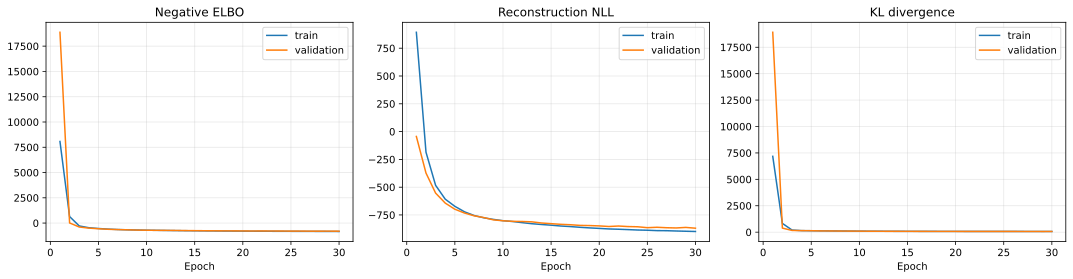

In [80]:
def plot_history(history):
    epochs_axis = np.arange(1, len(history['train_elbo']) + 1)
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    curves = [
        ('elbo', 'Negative ELBO'),
        ('recon', 'Reconstruction NLL'),
        ('KLD', 'KL divergence'),
    ]

    for ax, (key, title) in zip(axes, curves):
        ax.plot(epochs_axis, history[f'train_{key}'], label='train')
        ax.plot(epochs_axis, history[f'val_{key}'], label='validation')
        ax.set_xlabel('Epoch')
        ax.set_title(title)
        ax.grid(alpha=0.3)
        ax.legend()

    plt.tight_layout()
    plt.show()

plot_history(history)


### Samples and Reconstructions


Samples generated from the prior:


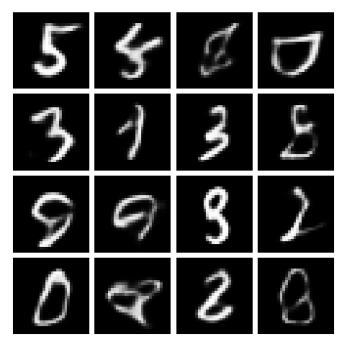

In [85]:
model.eval()

print('Samples generated from the prior:')
with torch.no_grad():
    generated = model.sample(16).cpu()
show_imgs(generated)

___
## Task 2
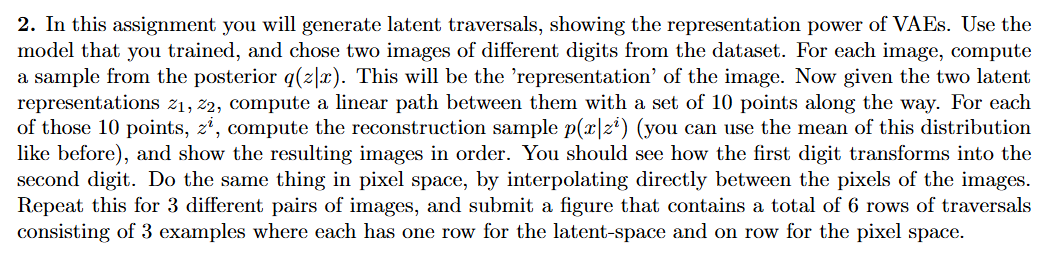
___

### Latent Traversals


In [93]:
def load_trained_vae_for_traversals():
    """
    Safely loads the trained VAE model from memory or disk for evaluation.
    
    This function acts as a robust checkpoint manager. It first checks if a 
    valid, trained model already exists in the global workspace to save time. 
    If not, it attempts to load the model's state dictionary and hyperparameters 
    from a saved file.
    
    Returns:
        model (VAE): The loaded model set to evaluation mode (.eval()).
        
    Raises:
        RuntimeError: If the model is not in memory and no checkpoint file exists.
    """
    global model, latent_dim, model_is_trained

    checkpoint_file = os.path.join(CHECKPOINT_PATH, 'vae_model.pth')
    
    # Check if model exists in memory and has logged training data
    model_available = 'model' in globals() and isinstance(model, VAE)
    has_training_logs = model_available and len(getattr(model, 'logs', {}).get('test_elbo', [])) > 0

    # If it's already trained and in memory, just set to eval and return
    if model_available and (globals().get('model_is_trained', False) or has_training_logs):
        model.eval()
        return model

    # If not in memory, load from disk
    if os.path.exists(checkpoint_file):
        checkpoint = torch.load(checkpoint_file, map_location=device)
        
        # Handle modern dictionary-based checkpoints (which store hyperparams)
        if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
            latent_dim = checkpoint.get('latent_dim', 32)
            decoder_sigma = checkpoint.get('decoder_sigma', 0.1)
            model = VAE(latent_dim=latent_dim, decoder_sigma=decoder_sigma).to(device)
            model.load_state_dict(checkpoint['model_state_dict'])
        # Handle older checkpoints that only saved the raw weights
        else:
            latent_dim = globals().get('latent_dim', 32)
            model = VAE(latent_dim=latent_dim, decoder_sigma=0.1).to(device)
            model.load_state_dict(checkpoint)

        model_is_trained = True
        model.eval() # Freeze dropout/batchnorm layers for inference
        print(f'Loaded trained VAE from {checkpoint_file}')
        return model

    raise RuntimeError(
        'Run the Task 1 training cell first, or make sure vae_model.pth exists in CHECKPOINT_PATH.'
    )


def first_index_for_digit(dataset, digit):
    """
    Finds the index of the first occurrence of a specific target class (digit) in the dataset.
    """
    targets = dataset.targets
    if isinstance(targets, torch.Tensor):
        matches = (targets == digit).nonzero(as_tuple=True)[0]
        return int(matches[0].item())

    return next(i for i, label in enumerate(targets) if int(label) == digit)


def get_fixed_digit_pairs(dataset, digit_pairs):
    """
    Retrieves the actual image tensors for specific pairs of digits.
    
    Args:
        dataset (Dataset): The PyTorch dataset (e.g., MNIST test set).
        digit_pairs (list of tuples): Expected classes to pair up, e.g., [(0, 1), (3, 8)].
        
    Returns:
        image_pairs (list of tuples): The actual (image_A, image_B) tensors.
        label_pairs (list of tuples): The corresponding (label_A, label_B) integers.
    """
    image_pairs = []
    label_pairs = []

    for digit_a, digit_b in digit_pairs:
        idx_a = first_index_for_digit(dataset, digit_a)
        idx_b = first_index_for_digit(dataset, digit_b)
        img_a, label_a = dataset[idx_a]
        img_b, label_b = dataset[idx_b]

        assert int(label_a) != int(label_b)
        image_pairs.append((img_a, img_b))
        label_pairs.append((int(label_a), int(label_b)))

    return image_pairs, label_pairs

# ==============================================================================
# MAIN EXECUTION: INTERPOLATION (TRAVERSALS)
# ==============================================================================

model = load_trained_vae_for_traversals()
model.eval()

num_steps = 10
digit_pairs = [(0, 1), (3, 8), (4, 9)]

# Create interpolation weights (alpha) from 0.0 to 1.0. 
# Math: alpha = [0.0, 0.11, 0.22, ..., 1.0]
alphas = torch.linspace(0, 1, num_steps, device=device)
image_pairs, label_pairs = get_fixed_digit_pairs(test_set, digit_pairs)

latent_rows = []
pixel_rows = []

# Disable gradient tracking to save memory and speed up inference
with torch.no_grad():
    for img_a, img_b in image_pairs:
        # Add batch dimension: shape becomes [1, 1, 28, 28]
        x_a = img_a.unsqueeze(0).to(device)
        x_b = img_b.unsqueeze(0).to(device)

        # ---------------------------------------------------------
        # 1. ENCODING INTO LATENT SPACE
        # Math: q(z|x) ~ Normal(mu, sigma^2)
        # ---------------------------------------------------------
        q_a, _, _ = model.encode(x_a)
        q_b, _, _ = model.encode(x_b)
        
        # Sample the actual vector representation for the images.
        # Math: z = mu + sigma * epsilon
        z_a = q_a.rsample()
        z_b = q_b.rsample()

        # ---------------------------------------------------------
        # 2. LATENT SPACE INTERPOLATION
        # Math: z(alpha) = (1 - alpha) * z_a + alpha * z_b
        # ---------------------------------------------------------
        # Reshape alpha to [num_steps, 1] for broadcasting against [1, latent_dim]
        alpha_z = alphas.view(num_steps, 1)
        
        # Linearly interpolate between the two vectors in the bottleneck space.
        # This creates a trajectory array of shape [10, latent_dim].
        z_path = (1 - alpha_z) * z_a + alpha_z * z_b
        
        # Decode the entire trajectory back into images.
        # Math: x_hat = decoder(z(alpha))
        latent_path = model.decode(z_path)

        # ---------------------------------------------------------
        # 3. PIXEL SPACE INTERPOLATION (The Baseline)
        # Math: x(alpha) = (1 - alpha) * x_a + alpha * x_b
        # ---------------------------------------------------------
        # Reshape alpha to [num_steps, 1, 1, 1] for broadcasting against image dimensions
        alpha_x = alphas.view(num_steps, 1, 1, 1)
        
        # Linearly blend the raw pixel intensities of image A and B.
        pixel_path = (1 - alpha_x) * x_a + alpha_x * x_b

        # Save to lists (moving back to CPU RAM to save GPU memory)
        latent_rows.append(latent_path.cpu())
        pixel_rows.append(pixel_path.cpu())

# Stack lists into final comparison tensors
latent_traversals = torch.stack(latent_rows)
pixel_traversals = torch.stack(pixel_rows)

# Sanity checks to ensure math and dimensions are correct
assert all(a != b for a, b in label_pairs)
# Expected shape: (3 pairs, 10 steps, 1 channel, 28 height, 28 width)
assert latent_traversals.shape == (3, num_steps, 1, 28, 28)
assert pixel_traversals.shape == (3, num_steps, 1, 28, 28)
assert latent_traversals.min().item() >= 0.0 and latent_traversals.max().item() <= 1.0

print('Selected digit pairs:', label_pairs)
print('Latent traversal shape:', tuple(latent_traversals.shape))
print('Pixel traversal shape:', tuple(pixel_traversals.shape))

Selected digit pairs: [(0, 1), (3, 8), (4, 9)]
Latent traversal shape: (3, 10, 1, 28, 28)
Pixel traversal shape: (3, 10, 1, 28, 28)


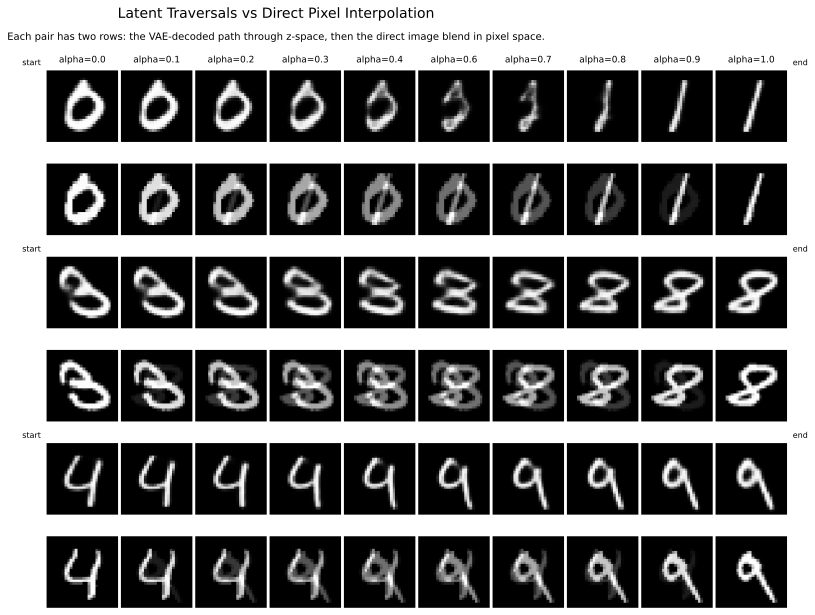

In [87]:
def plot_latent_and_pixel_traversals(latent_traversals, pixel_traversals, label_pairs, alphas):
    num_pairs, num_steps = latent_traversals.shape[:2]
    fig, axes = plt.subplots(
        2 * num_pairs,
        num_steps,
        figsize=(1.45 * num_steps, 1.45 * 2 * num_pairs),
    )

    row_descriptions = {
        'latent': 'latent space: decode((1-alpha) z1 + alpha z2)',
        'pixel': 'pixel space: (1-alpha) x1 + alpha x2',
    }

    for pair_idx, (digit_a, digit_b) in enumerate(label_pairs):
        latent_row = 2 * pair_idx
        pixel_row = latent_row + 1

        for step_idx in range(num_steps):
            axes[latent_row, step_idx].imshow(
                latent_traversals[pair_idx, step_idx, 0], cmap='gray', vmin=0, vmax=1
            )
            axes[pixel_row, step_idx].imshow(
                pixel_traversals[pair_idx, step_idx, 0], cmap='gray', vmin=0, vmax=1
            )

            axes[latent_row, step_idx].axis('off')
            axes[pixel_row, step_idx].axis('off')

            if pair_idx == 0:
                axes[latent_row, step_idx].set_title(
                    f'alpha={alphas[step_idx].item():.1f}', fontsize=9, pad=8
                )

        axes[latent_row, 0].set_ylabel(
            f'{digit_a} -> {digit_b}\n{row_descriptions["latent"]}',
            rotation=0,
            labelpad=108,
            va='center',
            ha='right',
            fontsize=9,
        )
        axes[pixel_row, 0].set_ylabel(
            f'{digit_a} -> {digit_b}\n{row_descriptions["pixel"]}',
            rotation=0,
            labelpad=108,
            va='center',
            ha='right',
            fontsize=9,
        )

        axes[latent_row, 0].text(
            -0.08, 1.05, 'start', transform=axes[latent_row, 0].transAxes,
            ha='right', va='bottom', fontsize=8
        )
        axes[latent_row, -1].text(
            1.08, 1.05, 'end', transform=axes[latent_row, -1].transAxes,
            ha='left', va='bottom', fontsize=8
        )

    fig.suptitle(
        'Latent Traversals vs Direct Pixel Interpolation',
        fontsize=14,
        y=0.995,
    )
    fig.text(
        0.5,
        0.955,
        'Each pair has two rows: the VAE-decoded path through z-space, then the direct image blend in pixel space.',
        ha='center',
        va='top',
        fontsize=10,
    )
    plt.subplots_adjust(left=0.28, right=0.99, top=0.90, bottom=0.03, wspace=0.04, hspace=0.18)
    plt.show()


plot_latent_and_pixel_traversals(latent_traversals, pixel_traversals, label_pairs, alphas.cpu())


___
## Task 3
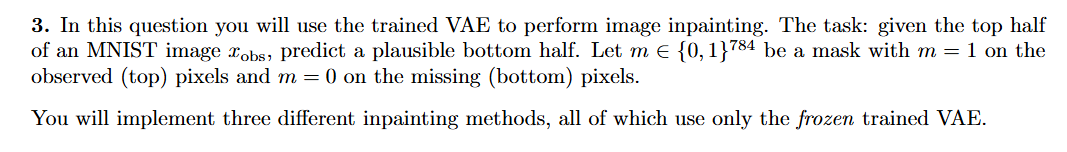
___

### Inpainting Setup


In [88]:
def load_trained_vae_for_inpainting():
    global model, latent_dim, model_is_trained

    checkpoint_file = os.path.join(CHECKPOINT_PATH, 'vae_model.pth')
    model_available = 'model' in globals() and isinstance(model, VAE)
    has_training_logs = model_available and len(getattr(model, 'logs', {}).get('test_elbo', [])) > 0

    if model_available and (globals().get('model_is_trained', False) or has_training_logs):
        model.eval()
    elif os.path.exists(checkpoint_file):
        checkpoint = torch.load(checkpoint_file, map_location=device)
        if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
            latent_dim = checkpoint.get('latent_dim', 32)
            decoder_sigma = checkpoint.get('decoder_sigma', 0.1)
            model = VAE(latent_dim=latent_dim, decoder_sigma=decoder_sigma).to(device)
            model.load_state_dict(checkpoint['model_state_dict'])
        else:
            latent_dim = globals().get('latent_dim', 32)
            model = VAE(latent_dim=latent_dim, decoder_sigma=0.1).to(device)
            model.load_state_dict(checkpoint)

        model_is_trained = True
        model.eval()
        print(f'Loaded trained VAE from {checkpoint_file}')
    else:
        raise RuntimeError(
            'Run the Task 1 training cell first, or make sure vae_model.pth exists in CHECKPOINT_PATH.'
        )

    for parameter in model.parameters():
        parameter.requires_grad_(False)

    return model


def first_index_for_label(dataset, label):
    targets = dataset.targets
    if isinstance(targets, torch.Tensor):
        matches = (targets == label).nonzero(as_tuple=True)[0]
        return int(matches[0].item())

    return next(i for i, target in enumerate(targets) if int(target) == label)


def select_fixed_inpainting_images(dataset, labels=(0, 1, 2, 3, 4, 5)):
    images = []
    selected_labels = []

    for label in labels:
        idx = first_index_for_label(dataset, label)
        image, actual_label = dataset[idx]
        images.append(image)
        selected_labels.append(int(actual_label))

    return torch.stack(images), selected_labels


def make_top_half_mask(batch_size=1):
    mask = torch.zeros(batch_size, 1, 28, 28, device=device)
    mask[:, :, :14, :] = 1.0
    return mask


model = load_trained_vae_for_inpainting()
x_gt, inpaint_labels = select_fixed_inpainting_images(test_set)
x_gt = x_gt.to(device)
mask = make_top_half_mask(batch_size=1)
observed_display = mask * x_gt + (1 - mask) * 0.5

assert x_gt.shape == (6, 1, 28, 28)
assert mask.shape == (1, 1, 28, 28)
assert torch.allclose(mask[:, :, :14, :], torch.ones_like(mask[:, :, :14, :]))
assert torch.allclose(mask[:, :, 14:, :], torch.zeros_like(mask[:, :, 14:, :]))
assert not any(parameter.requires_grad for parameter in model.parameters())

print('Selected labels:', inpaint_labels)
print('Images shape:', tuple(x_gt.shape))
print('Mask shape:', tuple(mask.shape))


Selected labels: [0, 1, 2, 3, 4, 5]
Images shape: (6, 1, 28, 28)
Mask shape: (1, 1, 28, 28)


### Plotting Helpers


In [89]:
def plot_inpainting_results(method_name, observed, ground_truth, result, labels):
    num_examples = ground_truth.size(0)
    fig, axes = plt.subplots(num_examples, 3, figsize=(6.2, 1.55 * num_examples))
    column_titles = ['Observed top half', 'Ground truth', 'Inpainted result']

    observed = observed.detach().cpu()
    ground_truth = ground_truth.detach().cpu()
    result = result.detach().cpu().clamp(0, 1)

    for col_idx, title in enumerate(column_titles):
        axes[0, col_idx].set_title(title, fontsize=10)

    for row_idx in range(num_examples):
        row_images = [observed[row_idx], ground_truth[row_idx], result[row_idx]]
        for col_idx, image in enumerate(row_images):
            axes[row_idx, col_idx].imshow(image[0], cmap='gray', vmin=0, vmax=1)
            axes[row_idx, col_idx].axis('off')

        axes[row_idx, 0].set_ylabel(
            f'label {labels[row_idx]}', rotation=0, labelpad=28, va='center', fontsize=9
        )

    fig.suptitle(method_name, fontsize=13, y=0.995)
    plt.subplots_adjust(left=0.16, right=0.98, top=0.93, bottom=0.02, wspace=0.06, hspace=0.14)
    plt.show()


def plot_method_a_snapshots(snapshot_dict, labels):
    iterations = list(snapshot_dict.keys())
    num_examples = next(iter(snapshot_dict.values())).size(0)
    fig, axes = plt.subplots(num_examples, len(iterations), figsize=(1.25 * len(iterations), 1.35 * num_examples))

    for col_idx, iteration in enumerate(iterations):
        axes[0, col_idx].set_title(f'iter {iteration}', fontsize=9)

    for row_idx in range(num_examples):
        for col_idx, iteration in enumerate(iterations):
            image = snapshot_dict[iteration][row_idx].detach().cpu().clamp(0, 1)
            axes[row_idx, col_idx].imshow(image[0], cmap='gray', vmin=0, vmax=1)
            axes[row_idx, col_idx].axis('off')

        axes[row_idx, 0].set_ylabel(
            f'label {labels[row_idx]}', rotation=0, labelpad=28, va='center', fontsize=9
        )

    fig.suptitle('Method (a) snapshots: encode-decode with clamping', fontsize=13, y=0.995)
    plt.subplots_adjust(left=0.16, right=0.98, top=0.91, bottom=0.02, wspace=0.04, hspace=0.12)
    plt.show()


def plot_inpainting_losses(map_losses, pixel_losses):
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))

    axes[0].plot(map_losses)
    axes[0].set_title('Method (b): MAP latent loss')
    axes[0].set_xlabel('Optimization step')
    axes[0].set_ylabel('Average loss')
    axes[0].grid(alpha=0.3)

    axes[1].plot(pixel_losses)
    axes[1].set_title('Method (c): pixel negative ELBO')
    axes[1].set_xlabel('Optimization step')
    axes[1].set_ylabel('Average loss')
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


### Method (a): Iterative Encode-Decode With Clamping
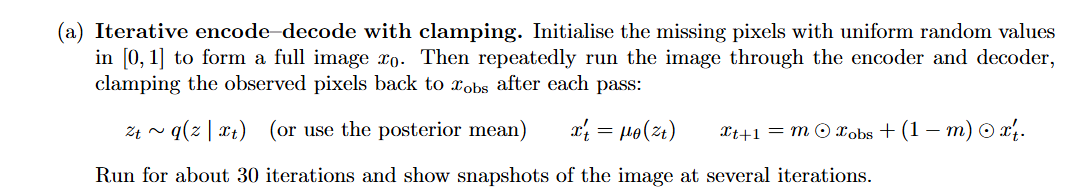

# A Theoretical and Practical Guide to VAE Image Inpainting

Image inpainting is the process of reconstructing missing or damaged parts of an image. When we use a frozen, pre-trained Variational Autoencoder (VAE) to do this, we are essentially relying on the model's learned understanding of the "rules" of the dataset (the latent manifold) to hallucinate a plausible completion.

The **Iterative Encode-Decode with Clamping** method is a powerful, gradient-free inference algorithm that forces the VAE to guess the missing pixels while strictly adhering to the pixels we already know.

Here is the deep dive into the theory, the mathematics, and the PyTorch implementation.

---

## 1. The Mathematical Framework

Before we loop, we must mathematically define the boundaries of our problem.

* **The Full Image ($x$):** An image of $784$ pixels ($28 \times 28$).
* **The Mask ($m$):** A binary matrix of the same shape where $m=1$ indicates a known pixel (the top half) and $m=0$ indicates a missing pixel (the bottom half).
* **The Observed Data ($x_{obs}$):** The true top half of the image.

### Initialization ($x_0$)

The VAE expects a full $28 \times 28$ image as input, so we cannot just pass it half an image. We must initialize the missing bottom half with something. While we could use zeros, using uniform random noise prevents the model from getting stuck in a dead state.

$$x_0 = m \odot x_{obs} + (1 - m) \odot \epsilon \quad \text{where} \quad \epsilon \sim U(0,1)$$

*(Note: $\odot$ denotes element-wise multiplication).*

---

## 2. The Iterative Loop Theory

Once we have our noisy initialized image $x_0$, we begin a cycle of encoding, decoding, and clamping. We repeat this cycle $T$ times (usually $T=30$).

### Step A & B: Encoding and Stochastic Sampling ($z_t$)

$$z_t \sim q_\phi(z|x_t) \quad \implies \quad z_t = \mu_\phi(x_t) + \sigma_\phi(x_t) \odot \epsilon$$

We pass the current image through the encoder network to project it into the bottleneck space. In this specific implementation, we use the **reparameterization trick (`.rsample()`)** to draw a stochastic sample from the distribution rather than extracting a fixed point.

Here is the theoretical trade-off between the two approaches:

* **The Stochastic Approach (Implemented):** By using `.rsample()`, we inject standard normal noise ($\epsilon$) into the process at every iteration. This forces the algorithm to constantly "explore" small, localized variations within the latent space. While this can prevent the model from getting stuck in a poor local minimum, it introduces randomness; the generated bottom half of the image will "flicker" or jitter across iterations rather than smoothly locking into place.
* **The Deterministic Alternative (The Posterior Mean):** If you want a smooth, perfectly stable convergence without any flickering, you would drop the noise entirely and strictly use the mean of the distribution: $z_t = \mu_\phi(x_t)$ (in PyTorch: `z_t = q_z_given_x.mean`). This provides a fixed mathematical anchor point at every step, relying purely on the encoder's absolute most confident guess.



### Step C: The Clamping Operation ($x_{t+1}$)

$$x_{t+1} = m \odot x_{obs} + (1 - m) \odot x'_t$$


This is the most critical step. The decoder's output ($x'_t$) will likely have altered the top half of the image (making it blurrier or shifting its position). We do not want this; the top half is absolute ground truth.
Therefore, we **clamp** the image: we take the pure ground truth $x_{obs}$ for the top half, and we splice it together with the decoder's newly hallucinated bottom half.

### Why does this converge?

Every time you clamp the true top half onto the model's generated bottom half, you create a slightly unnatural "seam" in the middle of the image. When you pass this clamped image *back* into the encoder for the next step, the encoder adjusts $z$ to try and fix that seam. Over 30 iterations, $z$ slowly walks across the latent manifold until it finds a digit concept that naturally satisfies the clamped top-half constraints.


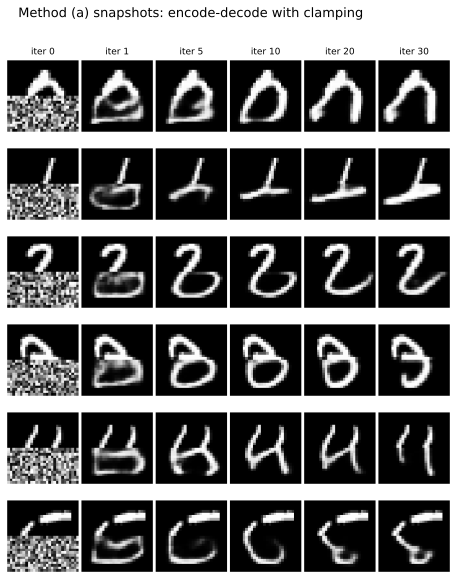

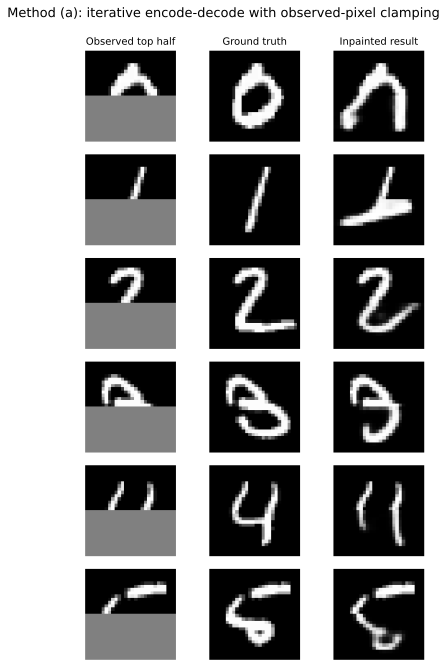

In [105]:
def inpaint_iterative_encode_decode(model, x, mask, num_iterations=30, snapshot_iterations=(0, 1, 5, 10, 20, 30)):
    """
    Performs image inpainting using iterative encoding, decoding, and clamping.
    
    Args:
        model: The trained VAE.
        x (Tensor): The ground truth image.
        mask (Tensor): Binary mask (1 for known pixels, 0 for missing pixels).
        num_iterations (int): Total number of clamp-decode cycles.
        snapshot_iterations (tuple): Specific iterations to save for visualization.
        
    Returns:
        Final inpainted image and a dictionary of snapshots over time.
    """
    snapshot_iterations = set(snapshot_iterations)
    snapshots = {}

    # Disable gradient computation since we are only doing inference
    with torch.no_grad():
        # ---------------------------------------------------------
        # 1. INITIALIZATION
        # Math: x_0 = (m * x_true) + ((1 - m) * noise)
        # We fill the missing regions (where mask == 0) with uniform random noise U(0,1).
        # ---------------------------------------------------------
        x_t = mask * x + (1 - mask) * torch.rand_like(x)
        
        if 0 in snapshot_iterations:
            snapshots[0] = x_t.detach().cpu()

        # ---------------------------------------------------------
        # 2. THE ITERATIVE LOOP
        # ---------------------------------------------------------
        for iteration in range(1, num_iterations + 1):
            
            # Step A: Encode the current noisy/clamped image
            # Math: q(z | x_t)
            q_z_given_x, _, _ = model.encode(x_t)
            
            # Step B: Sample from the latent space
            # Math: z_t = mu + sigma * epsilon
            # Note: Using rsample() injects stochastic noise at every step. 
            # If you want deterministic convergence, you can change this to: z_t = q_z_given_x.mean
            z_t = q_z_given_x.rsample()
            
            # Step C: Decode the latent vector into a full image prediction
            # Math: x'_t = Decoder(z_t)
            decoded = model.decode(z_t)
            
            # Step D: The Clamping Operation
            # Math: x_{t+1} = (m * x_true) + ((1 - m) * x'_t)
            # We forcefully overwrite the known pixels back to their ground-truth values,
            # keeping only the decoder's prediction for the missing areas.
            x_t = mask * x + (1 - mask) * decoded

            # Save the current state of the image if it's one of our target iterations
            if iteration in snapshot_iterations:
                snapshots[iteration] = x_t.detach().cpu()

    # Return the final image, clamped strictly between [0.0, 1.0] for safe plotting,
    # along with the history of the process.
    return x_t.detach().clamp(0, 1), snapshots


# ==========================================
# EXECUTION & EVALUATION
# ==========================================
# Run the algorithm on the ground truth (x_gt)
method_a_result, method_a_snapshots = inpaint_iterative_encode_decode(model, x_gt, mask)

# Sanity checks to ensure tensor dimensions and pixel ranges are valid
assert method_a_result.shape == x_gt.shape
assert method_a_result.min().item() >= 0.0 and method_a_result.max().item() <= 1.0
assert all(snapshot.shape == x_gt.shape for snapshot in method_a_snapshots.values())

# Plot the progression over time (Iter 0 -> Iter 30)
plot_method_a_snapshots(method_a_snapshots, inpaint_labels)

# Plot the final comparison (Masked Input vs. Ground Truth vs. Final Inpainted)
plot_inpainting_results(
    'Method (a): iterative encode-decode with observed-pixel clamping',
    observed_display,
    x_gt,
    method_a_result,
    inpaint_labels,
)

### Method (b): MAP Estimate of z by Gradient Descent
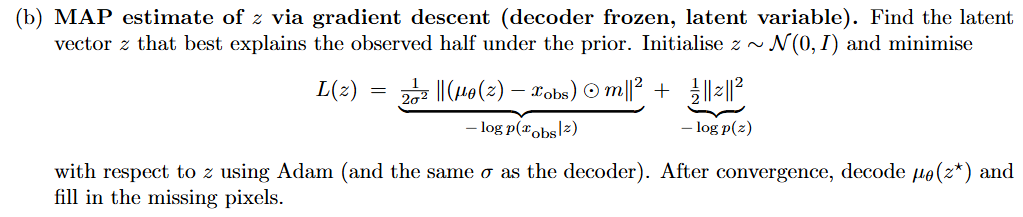

Here is the seamlessly integrated document. I have woven the step-by-step Bayes' rule derivation directly into "The Mathematical Framework" section so that it flows perfectly from the initial definition of MAP estimation right into the specific loss function components.

---

# A Theoretical and Practical Guide to VAE Inpainting: MAP Estimation via Gradient Descent

While the previous method (Iterative Encode-Decode) relied on the encoder to guess the latent vector, this method takes a completely different, optimization-based approach.

Here, we **completely ignore the encoder**. Instead, we treat the latent vector $z$ as a set of learnable weights. We start with a random $z$, push it through the frozen decoder, and look at how badly the generated top half mismatches the true top half. We then use **Gradient Descent (Backpropagation)** to directly update the numbers inside $z$ until the decoder outputs a top half that perfectly matches our ground truth.

Here is the deep dive into the Maximum A Posteriori (MAP) theory, the math, and the PyTorch implementation.

---

## 1. The Mathematical Framework

We want to find the single best latent vector $z^*$ that is most probable given the pixels we can see ($x_{obs}$). Mathematically, we want to maximize the posterior distribution. This is called **Maximum A Posteriori (MAP) Estimation**:

$$\arg\max_z p(z | x_{obs})$$

To transform this conceptual goal into a computable loss function, we perform a step-by-step mathematical derivation:

**Step 1: Apply Bayes' Rule**
Bayes' theorem allows us to flip the conditional probability so we can frame it in terms of our generative model (the decoder):


$$p(z | x_{obs}) = \frac{p(x_{obs} | z) p(z)}{p(x_{obs})}$$

**Step 2: Drop the Denominator**
As far as $z$ is concerned, the evidence denominator $p(x_{obs})$ is a constant value. Changing $z$ does not change the inherent probability of the observed image existing. Because we only care about *maximizing* with respect to $z$, we can safely drop it. The relationship becomes proportional ($\propto$):


$$\arg\max_z p(z | x_{obs}) \propto \arg\max_z \left[ p(x_{obs} | z) \cdot p(z) \right]$$

**Step 3: Apply the Logarithm**
In machine learning, multiplying raw probabilities leads to numerical underflow, and it is mathematically messy to differentiate. Because the natural logarithm is a strictly increasing function, applying it does not change *where* the maximum occurs, but it beautifully turns the multiplication into addition:


$$\arg\max_z \left[ \log p(x_{obs} | z) + \log p(z) \right]$$

**Step 4: Convert to a Minimization Problem**
PyTorch optimizers (like Adam) are designed to descend gradients—they only know how to **minimize** loss functions. Maximizing a value is mathematically identical to minimizing its negative. So, we multiply the entire expression by $-1$:


$$\arg\min_z \left[ -\log p(x_{obs} | z) - \log p(z) \right]$$

### The Objective Function

By applying Bayes' rule and taking the negative logarithm, our objective function cleanly splits into two distinct forces to be minimized:

$$\mathcal{L}(z) = -\log p(x_{obs}|z) - \log p(z)$$


---

### Part A: Deriving the Likelihood Term (Reconstruction)

In a Variational Autoencoder, the decoder defines the probability of an image $x$ given the latent vector $z$ as an isotropic multivariate Gaussian distribution.

**1. The Basic Probability Function**
The decoder outputs the mean $\mu_\theta(z)$ of the pixels, and we assume a fixed variance $\sigma^2$. The PDF for the *full* image is:


$$p(x|z) = \frac{1}{(2\pi\sigma^2)^{D/2}} \exp\left( -\frac{1}{2\sigma^2} \|x - \mu_\theta(z)\|^2 \right)$$


*(Where $D$ is the total number of pixels, 784 for MNIST).*

**2. Applying the Mask for Observed Pixels**
We only care about the observed top half ($x_{obs}$). Because the VAE assumes pixel probabilities are independent given $z$ (a diagonal covariance matrix), we can isolate just the pixels where the mask $m = 1$. The sum of squared errors is multiplied element-wise by the mask $m$:


$$p(x_{obs}|z) = \frac{1}{(2\pi\sigma^2)^{D_{obs}/2}} \exp\left( -\frac{1}{2\sigma^2} \sum_{i=1}^{D} m_i (x_i - \mu_\theta(z)_i)^2 \right)$$

We can rewrite that summation using vector notation (the L2 norm and the element-wise multiplication $\odot$):


$$p(x_{obs}|z) = \frac{1}{(2\pi\sigma^2)^{D_{obs}/2}} \exp\left( -\frac{1}{2\sigma^2} \| (\mu_\theta(z) - x) \odot m \|^2 \right)$$

**3. Taking the Negative Logarithm**
Now, we apply $-\log()$ to the entire equation. By the rules of logarithms, $-\log(A \cdot e^B) = -\log(A) - B$:


$$-\log p(x_{obs}|z) = -\log\left(\frac{1}{(2\pi\sigma^2)^{D_{obs}/2}}\right) - \left( -\frac{1}{2\sigma^2} \| (\mu_\theta(z) - x_{obs}) \odot m \|^2 \right)$$

**4. Dropping the Constants**
This simplifies to:


$$-\log p(x_{obs}|z) = \frac{D_{obs}}{2}\log(2\pi\sigma^2) + \frac{1}{2\sigma^2} \| (\mu_\theta(z) - x_{obs}) \odot m \|^2$$

Because we are doing gradient descent to optimize $z$, any term that does not contain $z$ acts as a constant flat plane. When PyTorch calculates the derivative (gradient), the derivative of a constant is zero. Therefore, we can completely drop the $\frac{D_{obs}}{2}\log(2\pi\sigma^2)$ term, leaving us with our final objective:

$$-\log p(x_{obs}|z) \approx \frac{1}{2\sigma^2} \| (\mu_\theta(z) - x_{obs}) \odot m \|^2$$

---

### Part B: Deriving the Prior Term (Regularization)

This derivation follows the exact same logic, but it is much simpler because the prior is a Standard Normal distribution centered at zero.

**1. The Basic Probability Function**
By definition, our prior $p(z)$ is $\mathcal{N}(0, I)$. This means the mean is $0$ and the variance is $1$. The PDF for a multivariate standard normal distribution with a latent dimension of $J$ is:


$$p(z) = \frac{1}{(2\pi)^{J/2}} \exp\left( -\frac{1}{2} \|z - 0\|^2 \right)$$

Which simplifies to:


$$p(z) = \frac{1}{(2\pi)^{J/2}} \exp\left( -\frac{1}{2} \|z\|^2 \right)$$

**2. Taking the Negative Logarithm**
Applying $-\log()$ splits the equation:


$$-\log p(z) = -\log\left(\frac{1}{(2\pi)^{J/2}}\right) - \left(-\frac{1}{2} \|z\|^2 \right)$$

$$-\log p(z) = \frac{J}{2}\log(2\pi) + \frac{1}{2} \|z\|^2$$

**3. Dropping the Constants**
Just like in Part A, the term $\frac{J}{2}\log(2\pi)$ contains no $z$ variable. It is a mathematical constant. When we pass this to the optimizer to minimize $z$, the derivative of that constant is zero. We drop it from our loss function calculation entirely:

$$-\log p(z) \approx \frac{1}{2} \|z\|^2$$
---

## 2. PyTorch Implementation Strategy

This implementation is unique because we are optimizing a *tensor*, not a neural network. We will set `requires_grad=True` on our random $z$ tensor, and pass that tensor directly into a PyTorch Adam optimizer.

MAP latent optimization:   0%|          | 0/500 [00:00<?, ?it/s]

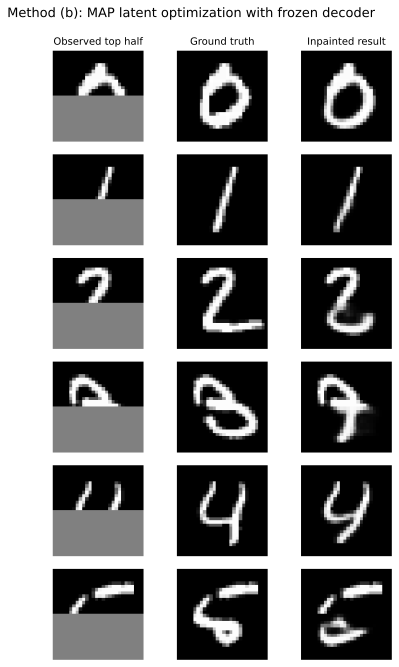

In [114]:
def inpaint_map_latent(model, x, mask, num_steps=500, lr=0.5):
    """
    Performs image inpainting via Maximum A Posteriori (MAP) estimation.
    
    Instead of using the encoder, this function treats the latent vector 'z' 
    as a set of learnable parameters. It uses Gradient Descent to find the 
    optimal 'z' that minimizes the negative log-posterior:
    
    Objective: minimize L(z) = -log p(x_obs | z) - log p(z)
    
    Args:
        model: The trained, frozen VAE model.
        x (Tensor): The ground truth image tensor.
        mask (Tensor): Binary mask (1 for known observed pixels, 0 for missing).
        num_steps (int): Number of optimization iterations (gradient descent steps).
        lr (float): Learning rate for the Adam optimizer.
        
    Returns:
        result (Tensor): The final inpainted image clamped between [0, 1].
        losses (list): The history of the loss values over the optimization steps.
    """
    
    # 1. INITIALIZE LATENT VECTOR (z)
    # Math: z ~ Normal(0, I)
    # CRITICAL: We set requires_grad=True so PyTorch tracks gradients for 'z' itself,
    # rather than the neural network weights (which remain frozen).
    z = torch.randn(x.size(0), model.latent_dim, device=x.device, requires_grad=True)
    
    # 2. INITIALIZE OPTIMIZER
    # We pass [z] to Adam, telling it to only update our latent vector.
    optimizer = optim.Adam([z], lr=lr)
    
    # Extract the constant variance scalar used during training (e.g., 0.1)
    sigma = model.decoder_sigma
    losses = []

    # 3. THE GRADIENT DESCENT OPTIMIZATION LOOP
    for step in tqdm(range(num_steps), leave=False, desc='MAP latent optimization'):
        # Clear old gradients from the previous step
        optimizer.zero_grad()
        
        # Step A: Decode the current guess for 'z' into a full image
        # Math: x_hat = Decoder(z)
        decoded = model.decode(z)
        
        # Step B: Calculate the Likelihood Term (Reconstruction Loss)
        # Math: -log p(x_obs | z) ~= (1 / 2*sigma^2) * sum( ((x_hat - x) * mask)^2 )
        # We multiply by 'mask' so the loss ONLY penalizes mistakes on the observed top half.
        # .flatten(1).sum(dim=1) sums the errors across all pixels for each image in the batch.
        reconstruction_term = 0.5 / (sigma ** 2) * (((decoded - x) * mask) ** 2).flatten(1).sum(dim=1)
        
        # Step C: Calculate the Prior Term (L2 Regularization)
        # Math: -log p(z) ~= 0.5 * sum( z^2 )
        # This acts as weight decay, pulling 'z' back towards 0 so the generated digit 
        # actually looks like a natural MNIST digit, preventing extreme unrealistic values.
        prior_term = 0.5 * (z ** 2).sum(dim=1)
        
        # Step D: Total MAP Objective
        # Math: L(z) = Likelihood + Prior
        per_example_loss = reconstruction_term + prior_term
        
        # Average the loss across the batch size to get a single scalar for backpropagation
        loss = per_example_loss.mean()
        
        # Step E: Backpropagation
        # Compute the gradients of the loss with respect to 'z'
        loss.backward()
        
        # Update the values inside 'z' to move down the gradient
        optimizer.step()
        
        # Track the loss to verify exponential decay/convergence later
        losses.append(loss.item())

    # 4. FINALIZATION
    # Disable gradients to build the final output image
    with torch.no_grad():
        # Decode the fully optimized z* vector
        decoded = model.decode(z)
        
        # The Clamping Operation: 
        # Force the observed pixels to perfectly match the ground truth (mask * x),
        # and fill the missing pixels with our optimized prediction ((1 - mask) * decoded).
        result = mask * x + (1 - mask) * decoded

    # Return the image, ensuring no pixel values drifted outside the valid [0, 1] rendering range
    return result.detach().clamp(0, 1), losses

# ==========================================
# EXECUTION & EVALUATION
# ==========================================

# Run the optimization loop. This returns the final image and the list of 500 loss values.
method_b_result, method_b_losses = inpaint_map_latent(model, x_gt, mask)

# Sanity Checks
assert method_b_result.shape == x_gt.shape
assert method_b_result.min().item() >= 0.0 and method_b_result.max().item() <= 1.0
assert len(method_b_losses) == 500

# Plot the final comparison (Masked Input vs. Ground Truth vs. Final Optimized Inpainting)
plot_inpainting_results(
    'Method (b): MAP latent optimization with frozen decoder',
    observed_display,
    x_gt,
    method_b_result,
    inpaint_labels,
)

### Method (c): Optimize Missing Pixels by Negative ELBO
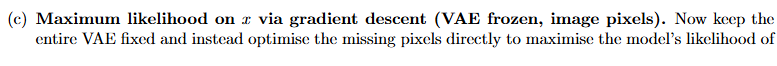
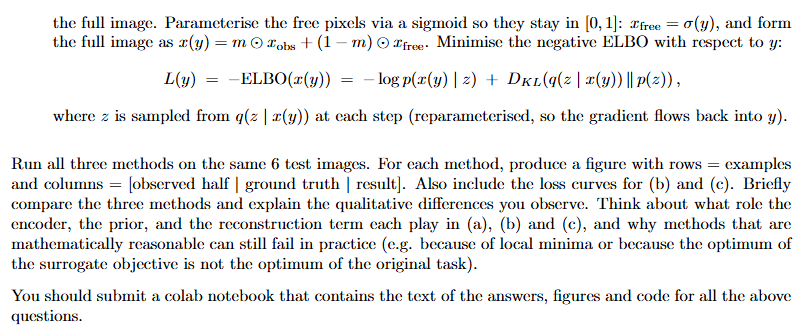


In Method (a), we relied on the network to iteratively guess the image. In Method (b), we optimized the latent "concept" ($z$). Now, in Method (c), we are going straight to the source: **we are using Gradient Descent to directly optimize the raw pixel values of the missing bottom half.**


---

### 1. The Theory: Maximum Likelihood on Pixels

In this method, we want to find the exact missing pixels that maximize the overall probability (Likelihood) of the final image existing under our VAE's learned distribution. Because calculating the true likelihood $p(x)$ is impossible, we maximize its surrogate: the **Evidence Lower Bound (ELBO)**.

**The Mathematical Setup:**

1. **The Free Variable ($y$):** Pixel values must stay between 0.0 (black) and 1.0 (white). If we optimize pixels directly, gradient descent might push them to 5.0 or -2.0. To fix this, we create an unconstrained variable $y$ and wrap it in a Sigmoid function:

$$x_{free} = \sigma(y)$$


2. **The Composite Image ($x(y)$):** We splice our fixed, true top half ($x_{obs}$) with our learnable bottom half ($x_{free}$):

$$x(y) = m \odot x_{obs} + (1 - m) \odot \sigma(y)$$


3. **The Objective:** We feed this composite image through the entire VAE and calculate the negative ELBO.

$$\mathcal{L}(y) = -ELBO(x(y)) = -\log p(x(y)|z) + D_{KL}(q(z|x(y)) || p(z))$$



**The Gradient Flow (Why the Reparameterization Trick is Mandatory here):**
When we call `.backward()`, the loss must trace all the way back to $y$.
Notice that $x(y)$ appears in two places:

1. It is the target in the reconstruction loss ($-\log p(x(y)|z)$).
2. It is the input to the Encoder to generate $z \sim q(z|x(y))$.

Because $z$ is drawn using the reparameterization trick ($z = \mu + \sigma \odot \epsilon$), the computational graph remains unbroken. The gradients flow beautifully from the loss, through the sampling step, through the encoder, and finally into your raw pixel tensor $y$.





Pixel optimization:   0%|          | 0/500 [00:00<?, ?it/s]

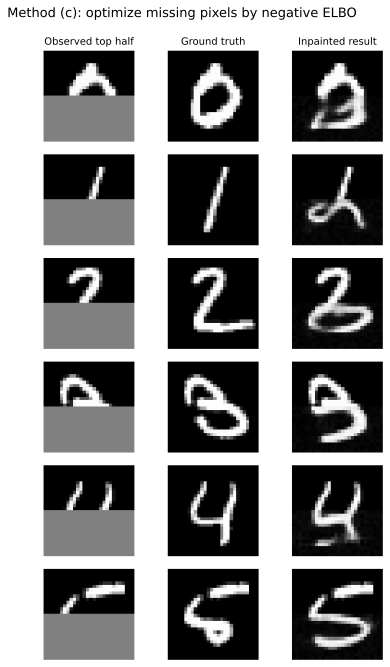

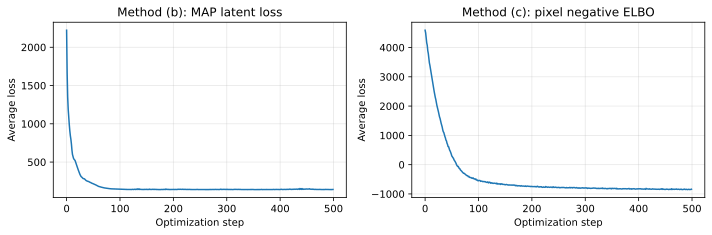

In [115]:
def inpaint_optimize_pixels(model, x, mask, num_steps=500, lr=0.05):
    """
    Method (c): Performs image inpainting by directly optimizing the unobserved 
    pixel values to maximize the Evidence Lower Bound (ELBO).
    
    Instead of adjusting latent variables, this method freezes the entire VAE 
    and treats the missing pixels themselves as optimization parameters. To 
    ensure pixels remain strictly within the valid range [0, 1], optimization 
    is performed in an unconstrained space (y) and mapped via a sigmoid function.
    
    Objective: minimize L(y) = -ELBO( x_composite(y) )
    
    Args:
        model: The trained, frozen VAE model.
        x (Tensor): The ground truth target image tensor.
        mask (Tensor): Binary mask (1 for known observed pixels, 0 for missing).
        num_steps (int): Number of optimization iterations.
        lr (float): Learning rate for the Adam optimizer.
        
    Returns:
        Tensor: The final composite inpainted image clamped between [0, 1].
        list: The history of the negative ELBO loss values across iterations.
    """
    model.eval()
    for param in model.parameters():
        param.requires_grad = False

    # 1. INITIALIZE PIXELS IN THE BOUNDED SPACE (0, 1)
    # We generate random noise between 0 and 1. We clamp slightly away from 
    # exact 0.0 and 1.0 (1e-4) to prevent logit() from evaluating to -inf or +inf.
    init_free_pixels = torch.rand_like(x).clamp(1e-4, 1 - 1e-4)
    
    # 2. MAP TO UNCONSTRAINED SPACE (y)
    # Math: y = log(p / (1 - p))
    # We apply the inverse-sigmoid (logit). This moves our parameters into 
    # the unconstrained real space (-inf, +inf) where Adam can safely optimize 
    # without running into hard boundary walls.
    y = torch.logit(init_free_pixels).detach().requires_grad_(True)
    
    # 3. INITIALIZE OPTIMIZER
    # We pass the unconstrained tensor [y] to Adam.
    optimizer = optim.Adam([y], lr=lr)
    losses = []

    # 4. OPTIMIZATION LOOP
    for step in tqdm(range(num_steps), leave=False, desc='Pixel optimization'):
        optimizer.zero_grad()
        
        # Step A: Project unconstrained parameters back into valid pixel intensities
        # Math: x_free = sigmoid(y), strictly bounding values within (0, 1)
        x_free = torch.sigmoid(y)
        
        # Step B: Construct the composite image
        # Math: x_current = (mask * x) + ((1 - mask) * x_free)
        # Keeps the true observed pixels intact while filling the missing slots with x_free.
        x_current = mask * x + (1 - mask) * x_free
        
        # Step C: Compute the negative ELBO loss
        # We pass the full composite image into the VAE. The method returns a tuple, 
        # where index [0] is the scalar negative ELBO value used as the loss.
        loss = model.calc_elbo(x_current)[0]
        
        # Step D: Backpropagation
        # The gradients flow backwards from the ELBO calculation, through the decoder 
        # reconstruction, through the reparameterized latent z, through the encoder, 
        # through the mask addition, and finally through the sigmoid derivative into y.
        loss.backward()
        optimizer.step()
        
        losses.append(loss.item())

    # 5. FINALIZATION
    with torch.no_grad():
        # Build the final static image using the optimized unconstrained values
        result = mask * x + (1 - mask) * torch.sigmoid(y)

    # Return the final image tensor and the loss trajectory
    return result.detach().clamp(0, 1), losses

# ==========================================
# EXECUTION, ASSERTIONS & PLOTTING
# ==========================================

# Run the pixel-space optimization routine
method_c_result, method_c_losses = inpaint_optimize_pixels(model, x_gt, mask)

# Technical Sanity Checks
assert method_c_result.shape == x_gt.shape
assert method_c_result.min().item() >= 0.0 and method_c_result.max().item() <= 1.0
assert len(method_c_losses) == 500

# Visualize visual results
plot_inpainting_results(
    'Method (c): optimize missing pixels by negative ELBO',
    observed_display,
    x_gt,
    method_c_result,
    inpaint_labels,
)

# Contrast convergence behavior between Latent Optimization (b) and Pixel Optimization (c)
plot_inpainting_losses(method_b_losses, method_c_losses)



# **Qualitative Differences & The Role of VAE Components**

---
## **Method (a) - Iterative Encode-Decode (Fixed-Point Iteration):**
* **Qualitative Result:** Tends to produce somewhat blurry but highly characteristic "average" digits. It usually provides the safest, most visually pleasing results to the human eye.
* **Component Roles:** The **Encoder** acts as a restorative operator—it looks at the unnatural, clamped image and pulls it toward the nearest valid cluster in the latent space. The **Decoder** hallucinates the completion.
* **Failure Modes:** Because it lacks a continuous, global objective function, it is not guaranteed to converge mathematically. If the top half is highly ambiguous (e.g., a circle that could be a 0, 8, or 9), the process can oscillate endlessly between different digits or settle into a blurry superposition of multiple numbers.
---

## **Method (b) - MAP on $z$ (Latent Space Optimization):**
* **Qualitative Result:** Produces incredibly sharp, defined digits, but they often "miss the mark" and fail to seamlessly connect to the ground-truth top half.
* **Component Roles:** The **Encoder** is completely bypassed. The **Prior** ($\frac{1}{2}\|z\|^2$) acts as a strict structural regularizer, forcing the hallucinated digit to look like a real number. The **Reconstruction Term** acts as the loss, desperately trying to force the decoder's top half to match the observed pixels.
* **Failure Modes (Local Minima):** This method fails due to the highly non-convex nature of the Decoder's neural network. If the optimizer initializes $z$ as a "3", but the top half belongs to an "8", the optimizer must alter $z$ to traverse the latent space. However, moving from the "3" cluster to the "8" cluster might temporarily *increase* the reconstruction loss. The optimizer refuses to cross this "hill" and gets stuck in a **local minimum**, resulting in a sharply rendered "3" awkwardly pasted beneath the top of an "8".
---

## **Method (c) - Maximum Likelihood on Pixels via ELBO:**
* **Qualitative Result:** Often produces noisy, grainy, or "adversarial" looking artifacts in the bottom half. It may technically complete the shape of the digit, but it looks unnatural and static-filled compared to (a) and (b).
* **Component Roles:** The **Encoder** acts as a discriminator, judging the composite image. The **Reconstruction** and **Prior** terms calculate the overall "validity" (ELBO) of the composite image.
* **Failure Modes (Surrogate Objective Mismatch):** This is a classic example of Goodhart's Law (*"When a measure becomes a target, it ceases to be a good measure"*). The mathematical optimum of the ELBO surrogate objective is **not** the optimum of human visual perception. By directly optimizing the raw pixels through gradient descent, we allow the optimizer to exploit mathematical loopholes in the frozen VAE. It finds configurations of high-frequency pixel noise that technically satisfy the Encoder and yield a high ELBO, but appear as unnatural, adversarial garbage to the human eye.



!